<a href="https://colab.research.google.com/github/skt12345678910/Buffalo_Bills_Win_Predictor/blob/main/Buffalo_Bills_Win_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nflreadpy

import pandas as pd
import numpy as np
import nflreadpy as nfl
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
raw_data = nfl.load_pbp(seasons=[2024, 2025]).to_pandas()

columns_needed = [
    'game_id', 'game_date', 'home_team', 'away_team', 'posteam', 'defteam', 'game_seconds_remaining',
    'score_differential', 'down', 'ydstogo', 'yardline_100', 'qtr', 'result', 'epa', 'spread_line', 'play_type'
]

df = raw_data[columns_needed].dropna().copy()
df = df[df['play_type'].isin(['pass', 'run'])].copy()
df['home_win'] = np.where(df['result'] > 0, 1, 0)

df['home_has_ball'] = np.where(df['posteam'] == df['home_team'], 1, 0)
df['home_score_diff'] = df['score_differential']
df['point_spread_value'] = df['spread_line']

df['is_second_half'] = np.where(df['qtr'] >= 3, 1, 0)
df['is_red_zone'] = np.where(df['yardline_100'] <= 20, 1, 0)
df['game_progress_ratio'] = df['game_seconds_remaining'] / 3600.0

df['point_spread'] = -df['point_spread_value']
df['spread_value_decay'] = df['point_spread'] * df['game_progress_ratio']
df['live_score_weight'] = df['home_score_diff'] * (1.0 - df['game_progress_ratio'])

df['home_play_epa'] = np.where(df['posteam'] == df['home_team'], df['epa'], -df['epa'])
df['home_cumulative_epa'] = df.groupby('game_id')['home_play_epa'].cumsum()
df['score_per_minute'] = df['home_score_diff'] / ((df['game_seconds_remaining'] + 1) / 60.0)
df['abs_score_diff'] = df['home_score_diff'].abs()

In [ ]:
features = [
    'game_seconds_remaining', 'home_score_diff', 'abs_score_diff', 'score_per_minute', 'home_cumulative_epa', 'home_has_ball',
    'yardline_100', 'down', 'ydstogo', 'point_spread', 'spread_value_decay', 'live_score_weight', 'is_second_half', 'is_red_zone'
]

bills_game_rows = df[(df['home_team'] == 'BUF') | (df['away_team'] == 'BUF')]
league_game_rows = df[(df['home_team'] != 'BUF') & (df['away_team'] != 'BUF')]

X_train = league_game_rows[features]
y_train = league_game_rows['home_win']
X_test = bills_game_rows[features]
y_test = bills_game_rows['home_win']

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 250], 'max_depth': [5, 6, 7], 'learning_rate': [0.03, 0.04, 0.05], 'subsample': [0.8, 0.85, 0.9]
}

base_model = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=base_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 60)
print("MODEL EVALUATION METRICS")
print("=" * 60)
print(f"Total Plays Trained On (League Wide): {len(X_train):,}")
print(f"Total Plays Tested On (Bills Only): {len(X_test):,}")
print("=" * 60)
print(f"Bills Full-Game Win or Loss Prediction Model Accuracy: {accuracy * 100:.2f}%")

MODEL EVALUATION METRICS
Total Plays Trained On (League Wide): 64,750
Total Plays Tested On (Bills Only): 4,656
Bills Full-Game Win or Loss Prediction Model Accuracy: 78.35%


MODEL FEATURES IMPORTANCE RANKINGS
01. home_cumulative_epa        45.62%
02. abs_score_diff             11.63%
03. point_spread               9.81%
04. spread_value_decay         7.67%
05. home_has_ball              6.07%
06. score_per_minute           5.44%
07. live_score_weight          4.28%
08. home_score_diff            3.38%
09. is_second_half             2.80%
10. game_seconds_remaining     1.74%
11. yardline_100               0.91%
12. ydstogo                    0.65%
13. is_red_zone                0.00%
14. down                       0.00%


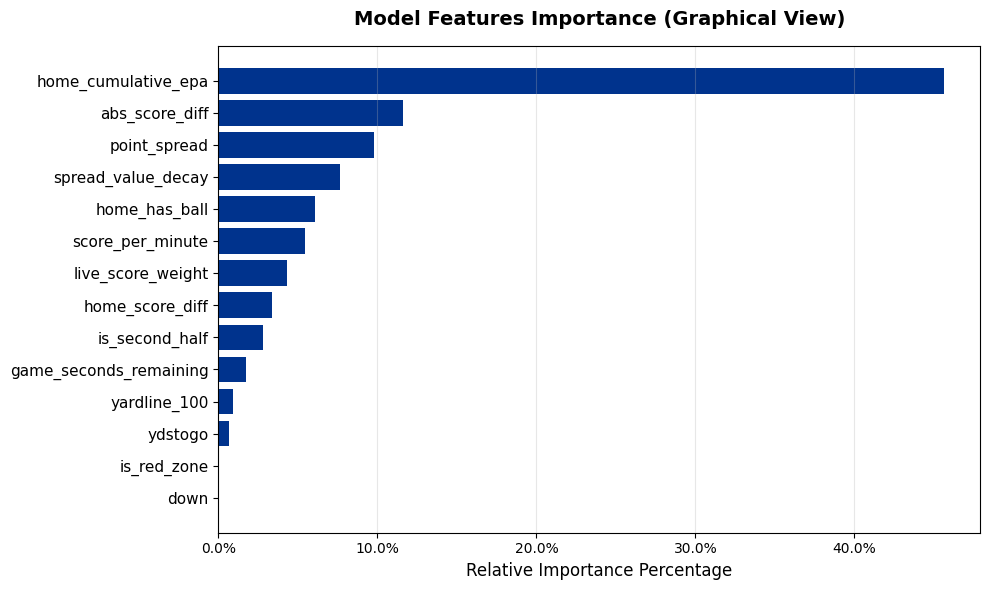

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

importances = model.feature_importances_
feature_names = features

indices = np.argsort(importances)[::-1]

print("MODEL FEATURES IMPORTANCE RANKINGS")
print("=" * 60)
for f in range(len(features)):
    print(f"{f + 1:02d}. {feature_names[indices[f]]:<25}  {importances[indices[f]] * 100:.2f}%")
print("=" * 60)

plt.figure(figsize=(10, 6))
plt.title("Model Features Importance (Graphical View)", fontsize=14, fontweight='bold', pad=15)
plt.barh(range(len(features)), importances[indices], color='#00338D', align='center')
plt.yticks(range(len(features)), [feature_names[i] for i in indices], fontsize=11)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('Relative Importance Percentage', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.show()

In [ ]:
#@title Buffalo Bills Live Prediction Model (Interactive) { run: "auto" }
#@markdown Fill out the real-time game situation below to get a Buffalo Bills win prediction.

where_is_game = "Home Game (Highmark Stadium)" #@param ["Home Game (Highmark Stadium)", "Away Game"]
quarter = 1 #@param {type:"slider", min:1, max:4, step:1}
minutes_remaining = 0 #@param {type:"slider", min:0, max:15, step:0}
seconds_remaining = 0 #@param {type:"slider", min:0, max:59, step:0}
winning_team = "Buffalo Bills" #@param ["Buffalo Bills", "Opposing Team", "Tie Game"]
score_difference = 0 #@param {type:"integer"}
possession = "Buffalo Bills" #@param ["Buffalo Bills", "Opposing Team"]
yards_to_endzone = 0 #@param {type:"integer"}
current_down = 1 #@param {type:"slider", min:1, max:4, step:1}
distance_to_first_down = 0 #@param {type:"integer"}
point_spread_for_bills = 0 #@param {type:"number"}

local_features = [
    'game_seconds_remaining', 'home_score_diff', 'abs_score_diff',
    'score_per_minute', 'home_cumulative_epa', 'home_has_ball',
    'yardline_100', 'down', 'ydstogo', 'point_spread',
    'spread_value_decay', 'live_score_weight', 'is_second_half', 'is_red_zone'
]

is_bills_home = (where_is_game == "Home Game (Highmark Stadium)")

if winning_team == "Buffalo Bills":
    bills_score_margin = abs(score_difference)
elif winning_team == "Opposing Team":
    bills_score_margin = -abs(score_difference)
else:
    bills_score_margin = 0

margin = bills_score_margin if is_bills_home else -bills_score_margin
has_ball = 1 if ((is_bills_home and possession == "Buffalo Bills") or (not is_bills_home and possession == "Opposing Team")) else 0
raw_home_spread_line = point_spread_for_bills if is_bills_home else -point_spread_for_bills

total_seconds_left = ((4 - quarter) * 900) + (minutes_remaining * 60) + seconds_remaining
game_progress_ratio = total_seconds_left / 3600.0
point_spread = raw_home_spread_line

spread_value_decay = point_spread * game_progress_ratio
live_score_weight = margin * (1.0 - game_progress_ratio)
score_per_minute = margin / ((total_seconds_left + 1) / 60.0)
estimated_cumulative_epa = margin * 0.75
is_second_half = 1 if quarter >= 3 else 0
is_red_zone = 1 if yards_to_endzone <= 20 else 0

scenario = pd.DataFrame([{
    'game_seconds_remaining': total_seconds_left, 'home_score_diff': margin, 'abs_score_diff': abs(margin),
    'score_per_minute': score_per_minute, 'home_cumulative_epa': estimated_cumulative_epa, 'home_has_ball': has_ball,
    'yardline_100': yards_to_endzone, 'down': current_down, 'ydstogo': distance_to_first_down, 'point_spread': point_spread,
    'spread_value_decay': spread_value_decay, 'live_score_weight': live_score_weight, 'is_second_half': is_second_half,
    'is_red_zone': is_red_zone
}])

scenario = scenario[local_features]

override_triggered = False

if total_seconds_left <= 10:
    if possession == "Opposing Team" and bills_score_margin >= 1 and yards_to_endzone > 50:
        prob_bills = 99.9
        override_triggered = True
    elif possession == "Buffalo Bills" and bills_score_margin <= -1 and yards_to_endzone > 50:
        prob_bills = 0.01
        override_triggered = True

if not override_triggered:
    prob_home = model.predict_proba(scenario)[0][1] * 100
    prob_bills = prob_home if is_bills_home else (100 - prob_home)

print("\n" + "=" * 54)
print("MODEL LIVE GAME PREDICTIONS")
print("=" * 54)
print(f"Location:       {where_is_game}")
print(f"Situation:      Quarter {quarter} | {minutes_remaining:02d}:{seconds_remaining:02d} remaining")
if bills_score_margin == 0:
    print(f"Game Score:     The game is TIED")
else:
    print(f"Leading Team:   {winning_team} by {abs(bills_score_margin)} points")
print(f"Possession:     {possession}")
print(f"Field Position: Down {current_down} & {distance_to_first_down} (Distance to Endzone: {yards_to_endzone} yds)")
print(f"Point Spread:   {'Bills favored by' if point_spread_for_bills <= 0 else 'Opponent favored by'} {abs(point_spread_for_bills)} points")
print("=" * 54)
print(f"Model Predicted BUFFALO BILLS Win Probability: {prob_bills:.1f}%")
print(f"Model Predicted OPPOSING TEAM Win Probability: {100 - prob_bills:.1f}%")


MODEL LIVE GAME PREDICTIONS
Location:       Home Game (Highmark Stadium)
Situation:      Quarter 1 | 00:00 remaining
Game Score:     The game is TIED
Possession:     Buffalo Bills
Field Position: Down 1 & 0 (Distance to Endzone: 0 yds)
Point Spread:   Bills favored by 0 points
Model Predicted BUFFALO BILLS Win Probability: 56.1%
Model Predicted OPPOSING TEAM Win Probability: 43.9%
